# 📊 Naive Bayes - Complete Learning Guide

## Overview
Naive Bayes is a probabilistic classifier based on Bayes' theorem. Despite its simplicity and "naive" assumption of feature independence, it often performs well in practice, especially for text classification and categorical data.

## Key Topics Covered:
1. **Bayes' Theorem** - Probability fundamentals
2. **Naive Assumption** - Feature independence
3. **Gaussian Naive Bayes** - Continuous features
4. **Multinomial Naive Bayes** - Text classification
5. **Bernoulli Naive Bayes** - Binary features
6. **Probability Estimation** - Laplace smoothing
7. **Real-world Applications** - Spam detection, sentiment analysis
8. **Advantages & Disadvantages** - When to use

---

## References:
- [Naive Bayes - Wikipedia](https://en.wikipedia.org/wiki/Naive_Bayes_classifier)
- [Bayes' Theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem)
- [scikit-learn Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🧮 Section 2: Bayes' Theorem & Naive Assumption

### Bayes' Theorem:
$$P(Class|Features) = \frac{P(Features|Class) \times P(Class)}{P(Features)}$$

### Naive Assumption:
Assumes features are conditionally independent given the class. This is rarely true but works well in practice!


🧮 EXAMPLE 1: Gaussian Naive Bayes

✅ Gaussian Naive Bayes Performance:
  Accuracy: 1.0000

📊 Class Prior Probabilities:
  setosa      : 0.3333
  versicolor  : 0.3417
  virginica   : 0.3250

📈 Feature Means by Class:
  setosa: [4.99   3.4525 1.45   0.245 ]
  versicolor: [5.9195122  2.77073171 4.24146341 1.32195122]
  virginica: [6.53333333 2.96666667 5.52051282 2.        ]


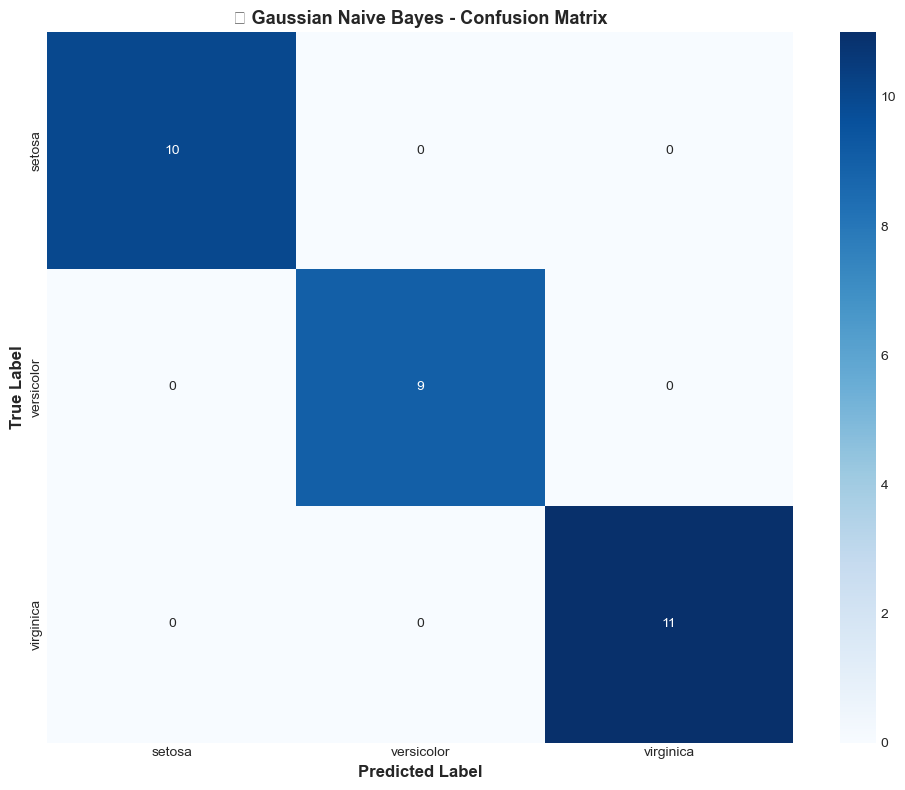

In [2]:
# Example 1: Gaussian Naive Bayes
print("\n" + "="*70)
print("🧮 EXAMPLE 1: Gaussian Naive Bayes")
print("="*70)

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_iris, y_train_iris)

# Predictions
y_pred_iris = gnb.predict(X_test_iris)
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)

print(f"\n✅ Gaussian Naive Bayes Performance:")
print(f"  Accuracy: {accuracy_iris:.4f}")

# Probability estimation
print(f"\n📊 Class Prior Probabilities:")
for i, class_name in enumerate(iris.target_names):
    prior = (y_train_iris == i).sum() / len(y_train_iris)
    print(f"  {class_name:12s}: {prior:.4f}")

# Mean and variance for each feature
print(f"\n📈 Feature Means by Class:")
for i, class_name in enumerate(iris.target_names):
    means = X_train_iris[y_train_iris == i].mean(axis=0)
    print(f"  {class_name}: {means}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_iris, y_pred_iris)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title('🧮 Gaussian Naive Bayes - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📄 Section 3: Multinomial Naive Bayes (Text Classification)

In [3]:
# Example 2: Multinomial Naive Bayes for Text
print("\n" + "="*70)
print("📄 EXAMPLE 2: Multinomial Naive Bayes (Text Classification)")
print("="*70)

# Sample text data
texts = [
    "I love machine learning, it's amazing",
    "This machine learning course is great",
    "I hate this boring task",
    "Machine learning is fun and useful",
    "This is so boring and tedious",
    "Learning is exciting and challenging",
    "I love coding and algorithms",
    "This sucks, terrible experience",
    "Python is great for machine learning",
    "Worst day ever, very frustrated"
]

labels = [1, 1, 0, 1, 0, 1, 1, 0, 1, 0]  # 1=positive, 0=negative

# Vectorize text
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(texts)

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_text, labels)

# Predictions
y_pred_text = mnb.predict(X_text)
accuracy_text = accuracy_score(labels, y_pred_text)

print(f"\n✅ Multinomial Naive Bayes Performance:")
print(f"  Accuracy (training): {accuracy_text:.4f}")

# Test new text
new_texts = [
    "I love this awesome machine learning",
    "This is terrible and boring"
]

X_new = vectorizer.transform(new_texts)
predictions = mnb.predict(X_new)
probabilities = mnb.predict_proba(X_new)

print(f"\n🔮 Predictions on New Text:")
for text, pred, probs in zip(new_texts, predictions, probabilities):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"  Text: {text}")
    print(f"  Prediction: {sentiment} (confidence: {max(probs):.2%})")
    print()


📄 EXAMPLE 2: Multinomial Naive Bayes (Text Classification)

✅ Multinomial Naive Bayes Performance:
  Accuracy (training): 1.0000

🔮 Predictions on New Text:
  Text: I love this awesome machine learning
  Prediction: Positive (confidence: 96.40%)

  Text: This is terrible and boring
  Prediction: Negative (confidence: 83.56%)



## 🔢 Section 4: Bernoulli Naive Bayes (Binary Features)

In [4]:
# Example 3: Bernoulli Naive Bayes
print("\n" + "="*70)
print("🔢 EXAMPLE 3: Bernoulli Naive Bayes (Binary Features)")
print("="*70)

# Load breast cancer (binary features possible)
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# Convert to binary (> median = 1, else 0)
X_cancer_binary = (X_cancer > X_cancer.mean(axis=0)).astype(int)

# Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_cancer_binary, y_cancer, test_size=0.2, random_state=42
)

# Train Bernoulli Naive Bayes
bnb = BernoulliNB()
bnb.fit(X_train_b, y_train_b)

# Predictions
y_pred_b = bnb.predict(X_test_b)
accuracy_b = accuracy_score(y_test_b, y_pred_b)

print(f"\n✅ Bernoulli Naive Bayes Performance:")
print(f"  Accuracy: {accuracy_b:.4f}")

# Metrics
precision_b = precision_score(y_test_b, y_pred_b)
recall_b = recall_score(y_test_b, y_pred_b)
f1_b = f1_score(y_test_b, y_pred_b)

print(f"  Precision: {precision_b:.4f}")
print(f"  Recall:    {recall_b:.4f}")
print(f"  F1 Score:  {f1_b:.4f}")


🔢 EXAMPLE 3: Bernoulli Naive Bayes (Binary Features)

✅ Bernoulli Naive Bayes Performance:
  Accuracy: 0.9825
  Precision: 0.9859
  Recall:    0.9859
  F1 Score:  0.9859


## 🎯 Section 5: Comparing Naive Bayes Variants


🎯 EXAMPLE 4: Comparing Naive Bayes Variants

✅ Naive Bayes Variants Comparison:
                Accuracy  Precision    Recall        F1
Gaussian NB     0.964912   0.958904  0.985915  0.972222
Multinomial NB  0.938596   0.910256  1.000000  0.953020
Bernoulli NB    0.982456   0.985915  0.985915  0.985915


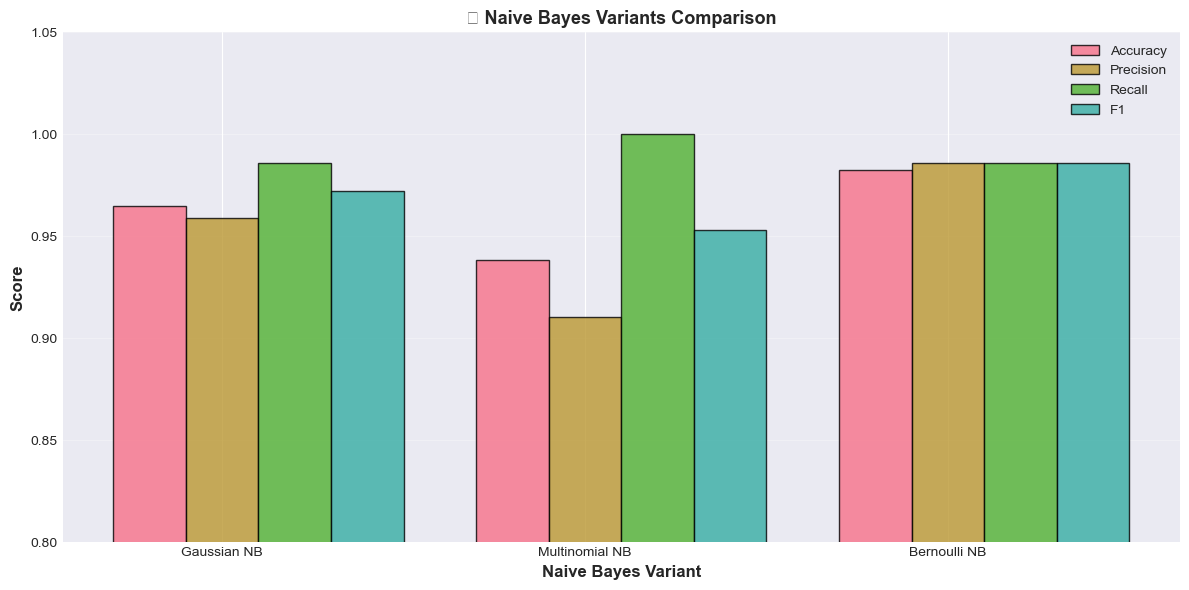

In [5]:
# Example 4: Comparison of Naive Bayes Variants
print("\n" + "="*70)
print("🎯 EXAMPLE 4: Comparing Naive Bayes Variants")
print("="*70)

# Split breast cancer dataset
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

# Scale for Gaussian NB
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cancer)
X_test_scaled = scaler.transform(X_test_cancer)

# Train models
models = {
    'Gaussian NB': GaussianNB(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB()
}

results = {}

for name, model in models.items():
    if name == 'Gaussian NB':
        model.fit(X_train_scaled, y_train_cancer)
        y_pred = model.predict(X_test_scaled)
    elif name == 'Multinomial NB':
        X_train_pos = np.clip(X_train_cancer, 0, None)  # Ensure non-negative
        X_test_pos = np.clip(X_test_cancer, 0, None)
        model.fit(X_train_pos, y_train_cancer)
        y_pred = model.predict(X_test_pos)
    else:  # Bernoulli
        X_train_b = (X_train_cancer > X_train_cancer.mean(axis=0)).astype(int)
        X_test_b = (X_test_cancer > X_train_cancer.mean(axis=0)).astype(int)
        model.fit(X_train_b, y_train_cancer)
        y_pred = model.predict(X_test_b)
    
    accuracy = accuracy_score(y_test_cancer, y_pred)
    precision = precision_score(y_test_cancer, y_pred)
    recall = recall_score(y_test_cancer, y_pred)
    f1 = f1_score(y_test_cancer, y_pred)
    
    results[name] = {'Accuracy': accuracy, 'Precision': precision,
                     'Recall': recall, 'F1': f1}

# Results
results_df = pd.DataFrame(results).T
print(f"\n✅ Naive Bayes Variants Comparison:")
print(results_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2

for i, metric in enumerate(results_df.columns):
    ax.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8, edgecolor='black')

ax.set_xlabel('Naive Bayes Variant', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('🎯 Naive Bayes Variants Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

## 📋 Section 6: Naive Bayes Advantages & Disadvantages

### ✅ Advantages:
1. **Fast training** - O(n) complexity
2. **Fast prediction** - Quick inference
3. **Works well with text** - Great for NLP tasks
4. **Handles high dimensions** - Works with many features
5. **Interpretable** - Easy to understand probabilities
6. **Requires small training data** - Works with limited samples
7. **Probabilistic** - Gives confidence scores

### ❌ Disadvantages:
1. **Naive assumption** - Features rarely truly independent
2. **Feature scaling** - Can be affected by feature magnitudes
3. **Zero frequency problem** - Needs smoothing
4. **Posterior estimates** - May not be accurate probabilities
5. **Not for complex patterns** - Simpler than modern methods
6. **Categorical features** - Needs adaptation for continuous data

### When to Use:
- Text classification (spam detection, sentiment analysis)
- Email filtering
- Real-time classification (fast)
- Baseline models
- Limited training data
- High-dimensional data

In [6]:
# Example 5: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "Naive Bayes uses Bayes' theorem for probabilistic classification",
    "Naive assumption: features are conditionally independent (unrealistic but works!)",
    "Gaussian NB: continuous features, assumes Gaussian distribution",
    "Multinomial NB: count data, great for text (word frequencies)",
    "Bernoulli NB: binary features (present/absent)",
    "Very fast training and prediction - good for real-time systems",
    "Works surprisingly well despite simplistic assumptions",
    "Great baseline model for text classification",
    "Handles high-dimensional data well",
    "Use Laplace smoothing to avoid zero probability issues"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. Naive Bayes uses Bayes' theorem for probabilistic classification

 2. Naive assumption: features are conditionally independent (unrealistic but works!)

 3. Gaussian NB: continuous features, assumes Gaussian distribution

 4. Multinomial NB: count data, great for text (word frequencies)

 5. Bernoulli NB: binary features (present/absent)

 6. Very fast training and prediction - good for real-time systems

 7. Works surprisingly well despite simplistic assumptions

 8. Great baseline model for text classification

 9. Handles high-dimensional data well

10. Use Laplace smoothing to avoid zero probability issues

